# Category Encoders: Catalog & Experiments (Part 1)

We shall explore 24 encoders from 4 libraries:

| library | one-hot encoders | other simple encoders | contrast encoders | target/Bayesian encoders |
| --- | --- | --- | --- | --- |
| [sklearn.preprocessing](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing) | OneHotEncoder | LabelEncoder <br> OrdinalEncoder <br> LabelBinarizer | |
| [category_encoders](https://contrib.scikit-learn.org/category_encoders) | OneHotEncoder | OrdinalEncoder <br> BinaryEncoder <br> BaseNEncoder <br> CountEncoder <br> HashingEncoder| HelmertEncoder <br> SumEncoder <br> BackwardDifferenceEncoder <br> PolynomialEncoder | TargetEncoder <br> MEstimateEncoder <br> WOEEncoder <br> JamesSteinEncoder <br> LeaveOneOutEncoder <br> CatBoostEncoder <br> GLMMEncoder |
| [pandas](https://pandas.pydata.org) | get_dummies | factorize | | |
| [keras.utils](https://keras.io/api/utils) | to_categorical | | | |

<br>
Encoders map the original categories (often dtype=string) to a set of representing values (often dtype=int for simple encoders; dtype=float for target encoders). This notebook walks through a tour of the encoders listed in the table, exploring each non-target encoder one by one, producing a comparison table at the end. Target encoders shall be explored in detail in a separate notebook.
<br><br>
When to use which encoder to solve what problems? There is a good guide here: [Encode Smarter: How to Easily Integrate Categorical Encoding into Your Machine Learning Pipeline](https://innovation.alteryx.com/encode-smarter).

In [1]:
from sklearn import preprocessing
from category_encoders import OrdinalEncoder, OneHotEncoder, BinaryEncoder, BaseNEncoder, CountEncoder, HashingEncoder
from category_encoders import HelmertEncoder, SumEncoder, BackwardDifferenceEncoder, PolynomialEncoder
from category_encoders import TargetEncoder, MEstimateEncoder, WOEEncoder, JamesSteinEncoder, LeaveOneOutEncoder, CatBoostEncoder, GLMMEncoder
from keras import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, gc, time
warnings.simplefilter('ignore') # once | error | always | default | module

# We shall be compiling a summary table as we go along.
summary = pd.DataFrame({'inp2out_map': pd.Series(dtype=object),   # input-to-output map
                        'nunique'    : pd.Series(dtype=int),      # number of unique (or distinct) values in output
                        'unique'     : pd.Series(dtype='object'), # unique values in output
                        'shape'      : pd.Series(dtype=int),      # rows-by-columns of output array
                        'tictoc'     : pd.Series(dtype=int)})     # computation time i seconds
summary.index.name = 'encoder'
# The grand summary is printed at the end of this notebook.

In [2]:
train = pd.read_csv('/kaggle/input/tabular-playground-series-mar-2021/train.csv', index_col='id') # [['cat10', 'cat5', 'target']]
train.sample(5)

,cat0,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,target
id,,,,,,,,,,,,,,,,,,,,,
321476,A,I,A,A,D,BI,A,AK,AN,A,...,0.462942,0.618920,0.813304,0.555013,0.418686,0.707380,0.601736,0.345328,0.421281,0
109117,A,I,A,A,E,BI,A,E,BM,C,...,0.400962,0.619782,0.809235,0.735738,0.442412,0.356082,0.457357,0.306377,0.335780,0
368330,A,I,A,A,F,H,E,E,BC,F,...,0.587119,0.344065,0.221772,0.557375,0.686368,0.377077,0.383746,0.585443,0.469464,0
127244,A,H,C,A,D,AB,A,AH,K,A,...,0.328959,0.336548,0.248593,0.553548,0.324864,0.320976,0.364163,0.520056,0.483455,0
254002,A,J,A,A,E,BI,E,AN,AK,A,...,0.291954,0.803738,0.379849,0.142770,0.137039,0.524975,0.599285,0.395820,0.673471,0


# Is encoding optional?
Not always. Some packages can't digest string-type data without encoding. 'Donkey', 'horse' and 'mule', for instance, would not work whereas 0, 1 and 2 would.

Even when the package can digest data without encoding, they sometimes learn encoded data better.

# Encoder types: a broad-stroke scan
We've got 2 dozen encoders here. Let's take an overview by trying to group them into families according to observable behaviors.

In [3]:
%%time
# Would the output differ whether or not we supply the target as input?
# Let's run a test with 10 encoders which optionally accept the target as input:
pick = train.columns[train.columns.str.startswith('cat')]
for ncoda in [OrdinalEncoder, HelmertEncoder, SumEncoder, OneHotEncoder, BinaryEncoder, BaseNEncoder, CountEncoder, BackwardDifferenceEncoder]:
    tis = ncoda().fit_transform(train[pick])
    tat = ncoda().fit_transform(train[pick], train['target']) 
#   Print 'True' if same; print 'False' otherwise
    print((tis==tat).all().all(), ncoda)

True <class 'category_encoders.ordinal.OrdinalEncoder'>
True <class 'category_encoders.helmert.HelmertEncoder'>
True <class 'category_encoders.sum_coding.SumEncoder'>
True <class 'category_encoders.one_hot.OneHotEncoder'>
True <class 'category_encoders.binary.BinaryEncoder'>
True <class 'category_encoders.basen.BaseNEncoder'>
True <class 'category_encoders.count.CountEncoder'>
True <class 'category_encoders.backward_difference.BackwardDifferenceEncoder'>
CPU times: user 3min 48s, sys: 2min 49s, total: 6min 38s
Wall time: 6min 36s


In [4]:
# Some encoders use the target for computing the output; they can't run without being given the target. These are the target encoders.
for ncoda in [TargetEncoder, MEstimateEncoder, WOEEncoder, JamesSteinEncoder, LeaveOneOutEncoder, CatBoostEncoder, GLMMEncoder]:
    try:
#       Run without train['target']:
        tis = ncoda().fit_transform(train[pick])
        print('Passed:', ncoda)    
    except Exception as complaint:
        print(complaint)
        print('See, told ya it was going to break:', ncoda)    
    gc.collect()

fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.target_encoder.TargetEncoder'>
fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.m_estimate.MEstimateEncoder'>
fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.woe.WOEEncoder'>
fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.james_stein.JamesSteinEncoder'>
fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.leave_one_out.LeaveOneOutEncoder'>
fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.cat_boost.CatBoostEncoder'>
fit_transform() missing argument: y
See, told ya it was going to break: <class 'category_encoders.glmm.GLMMEncoder'>


In [5]:
# Let's do a scan for encoders which output a column named, 'intercept', which suggests contrast encoding, which we will see in the last section.
for ncoda in [OrdinalEncoder, OneHotEncoder, BinaryEncoder, BaseNEncoder, CountEncoder, HashingEncoder,
              HelmertEncoder, SumEncoder, BackwardDifferenceEncoder, PolynomialEncoder]:
    out = ncoda().fit_transform(train[pick])
    if 'intercept' in out.columns:
        print(str(ncoda))

<class 'category_encoders.helmert.HelmertEncoder'>
<class 'category_encoders.sum_coding.SumEncoder'>
<class 'category_encoders.backward_difference.BackwardDifferenceEncoder'>
<class 'category_encoders.polynomial.PolynomialEncoder'>


# One-to-one simple, target-independent encoders

In [6]:
# Let's zoom into a single column.
train['cat10'].nunique(), train['cat10'].unique()
# cat10 alone has 299 unique values altogether. This value in termed 'cardinality'.
# This is an extreme case. Cardinalities are usually lower e.g. exam grades = A, B, C, D, E would have cardinality=5.

(299,
 array(['LO', 'HJ', 'DJ', 'KV', 'DP', 'GE', 'HQ', 'HC', 'EK', 'GS', 'HG',
        'BY', 'HX', 'JK', 'FJ', 'LM', 'HK', 'MD', 'IG', 'JG', 'AN', 'AD',
        'MC', 'KW', 'CK', 'LF', 'CS', 'GK', 'DC', 'LB', 'FM', 'IH', 'LN',
        'IK', 'DF', 'IB', 'CB', 'LY', 'JW', 'FI', 'CR', 'IE', 'LE', 'HB',
        'HV', 'LG', 'BG', 'KP', 'LI', 'HL', 'BF', 'LU', 'O', 'GI', 'DQ',
        'IR', 'DV', 'HA', 'KB', 'FP', 'AT', 'IF', 'HN', 'GC', 'C', 'KC',
        'G', 'JA', 'CU', 'BC', 'AB', 'KF', 'MB', 'HE', 'BL', 'FQ', 'IA',
        'MJ', 'FO', 'V', 'JT', 'AU', 'IO', 'GQ', 'CC', 'JR', 'BM', 'HH',
        'AV', 'GT', 'I', 'IU', 'JN', 'EV', 'MV', 'EQ', 'LW', 'FN', 'IT',
        'AA', 'DK', 'IJ', 'GU', 'P', 'JH', 'CM', 'GA', 'R', 'LX', 'IX',
        'DY', 'D', 'FL', 'CP', 'GL', 'DI', 'CD', 'IV', 'FS', 'FR', 'J',
        'MP', 'MH', 'EL', 'JD', 'AP', 'AE', 'F', 'LC', 'BP', 'BI', 'MF',
        'DO', 'MG', 'MT', 'LD', 'CW', 'KS', 'BV', 'JV', 'BB', 'AM', 'KX',
        'FK', 'AH', 'LV', 'W', 'DU', 'FB',

In [7]:
%%time
for which in [preprocessing.LabelEncoder, preprocessing.OrdinalEncoder, OrdinalEncoder,  # Section 1
              preprocessing.OneHotEncoder, OneHotEncoder,                                # Section 2
              preprocessing.LabelBinarizer, BinaryEncoder, BaseNEncoder,                 # Section 3
              CountEncoder,                                                              # Section 4
              HelmertEncoder, SumEncoder, BackwardDifferenceEncoder]:                    # Section 5
    if which==preprocessing.OrdinalEncoder or which==preprocessing.OneHotEncoder: 
        inp = train['cat10'].values.reshape(-1, 1)
    else:
        inp = train['cat10']

    tic = time.time()
    if which==preprocessing.OneHotEncoder: 
        out = which(sparse=False).fit_transform(inp)
    else:
        out = which().fit_transform(inp)
    tictoc = time.time() - tic

    inp2out_map = pd.concat([pd.DataFrame({'inp': train['cat10']}, columns=['inp']),
                             pd.DataFrame(out, index=train.index)], axis=1).drop_duplicates()
    inp2out_map.set_index('inp', inplace=True, drop=True)
    unik = np.unique(inp2out_map.values)
#   Grab the label, apply some minor hiding cosmetics:
    label = str(which).replace("<class '", "").replace("'>", "")
    if inp2out_map.isnull().any().any():
        print(label, "doesn't map one-to-one")
    summary.loc[label] = inp2out_map, len(unik), unik, inp2out_map.shape, tictoc
columns_show = ['nunique', 'unique', 'shape', 'tictoc']
summary[columns_show]

CPU times: user 29.3 s, sys: 8.26 s, total: 37.5 s
Wall time: 37.5 s


,nunique,unique,shape,tictoc
encoder,,,,
sklearn.preprocessing._label.LabelEncoder,299,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(299, 1)",0.109889
sklearn.preprocessing._encoders.OrdinalEncoder,299,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","(299, 1)",0.146098
category_encoders.ordinal.OrdinalEncoder,299,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(299, 1)",0.104805
sklearn.preprocessing._encoders.OneHotEncoder,2,"[0.0, 1.0]","(299, 299)",1.543521
category_encoders.one_hot.OneHotEncoder,2,"[0, 1]","(299, 299)",4.226416
sklearn.preprocessing._label.LabelBinarizer,2,"[0, 1]","(299, 299)",7.235379
category_encoders.binary.BinaryEncoder,2,"[0, 1]","(299, 10)",0.252719
category_encoders.basen.BaseNEncoder,2,"[0, 1]","(299, 10)",0.220429
category_encoders.count.CountEncoder,204,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(299, 1)",0.177695


# 1. Label & Ordinal encoders
From the table we find the first 3 rows:
* sklearn.preprocessing._label.LabelEncoder
* sklearn.preprocessing._encoders.OrdinalEncoder
* category_encoders.ordinal.OrdinalEncoder

rather similar to each other:
* they all output 299 unique numbers, where 299 is the cardinality of the original input;
* they all output a single column;
* they basically do one-to-one mapping of the original input;
* they run quickly compared to the rest.

## 1.1 LabelEncoder vs OrdinalEncoder
* LabelEncoder encodes one variable at a time; meant for encoding target labels (as in classification problems). 
* OrdinalEncoder encodes multiple variables/columns at a time; meant for encoding features (plural).

Let's see that in action:

In [8]:
try:
    out = LabelEncoder().fit_transform(train[['cat10', 'cat5']])
except Exception as complaint:
    print(complaint)
    print('See, told ya it was going to break.')    

name 'LabelEncoder' is not defined
See, told ya it was going to break.


In [9]:
out = OrdinalEncoder().fit_transform(train[['cat10', 'cat5']])
# no complains

## 1.2 pandas does label encoding too

In [10]:
def redressOutput(out):
    inp2out_map = pd.concat([pd.DataFrame({'inp': train['cat10']}, columns=['inp']),
                             pd.DataFrame(out, index=train.index)], axis=1).drop_duplicates()
    inp2out_map.set_index('inp', inplace=True, drop=True)
    unik = np.unique(inp2out_map.values)
    return inp2out_map, len(unik), unik, inp2out_map.shape

In [11]:
tic = time.time()
out = pd.factorize(train['cat10'])[0]
tictoc = time.time() - tic
summary.loc['pd.factorize'] = redressOutput(out) + (tictoc, )

labelordinal_encoders = ['sklearn.preprocessing._label.LabelEncoder',
                         'sklearn.preprocessing._encoders.OrdinalEncoder',
                         'category_encoders.ordinal.OrdinalEncoder',
                         'pd.factorize']
summary.loc[labelordinal_encoders, columns_show ]

,nunique,unique,shape,tictoc
encoder,,,,
sklearn.preprocessing._label.LabelEncoder,299,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(299, 1)",0.109889
sklearn.preprocessing._encoders.OrdinalEncoder,299,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","(299, 1)",0.146098
category_encoders.ordinal.OrdinalEncoder,299,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(299, 1)",0.104805
pd.factorize,299,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(299, 1)",0.023000


In [12]:
# like scikit's LabelEncoder, pd.factorize can only handle one column at a time
try:
    out = pd.factorize(train[['cat10', 'cat5']])
except Exception as complaint:
    print(complaint)
    print('See, told ya it was going to break.')    

could not broadcast input array from shape (300000,2) into shape (300000)
See, told ya it was going to break.


# 2. One-hot encoders
## 2.1 by scikit-learn and catagory-encoders

In [13]:
summary.loc[ summary.index.str.contains('OneHot') , columns_show ]
# We've got two one-hot encoders so far. One from sklearn.preprocessing; another by category_encoders. Both work in a similar way. We can use either.

,nunique,unique,shape,tictoc
encoder,,,,
sklearn.preprocessing._encoders.OneHotEncoder,2,"[0.0, 1.0]","(299, 299)",1.543521
category_encoders.one_hot.OneHotEncoder,2,"[0, 1]","(299, 299)",4.226416


Compared to label and ordinal encoders, we find that with one-hot encoders:
* ```nunique``` dropped from 299 to 2;
* the number of columns increased from 1 to 299.

Let's see how a one-hot encoder maps input to output:

In [14]:
inp2out_map = summary.loc['category_encoders.one_hot.OneHotEncoder', 'inp2out_map']
inp2out_map

,cat10_1,cat10_2,cat10_3,cat10_4,cat10_5,cat10_6,cat10_7,cat10_8,cat10_9,cat10_10,...,cat10_290,cat10_291,cat10_292,cat10_293,cat10_294,cat10_295,cat10_296,cat10_297,cat10_298,cat10_299
inp,,,,,,,,,,,,,,,,,,,,,
LO,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HJ,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DJ,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KV,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DP,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
JF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
BA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
LK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


One-hot encoding is thus name because for each row there is strictly one 1; all other columns must be zero. Let's do a quick check:

In [15]:
for row_idx, row_data in inp2out_map.iterrows():
    vcount = row_data.value_counts().sort_index()
    if not (vcount==pd.Series({0: 298, 1: 1})).all():
        print('oopsy')
# Loop passes without any oopsy, confirming that each row had strictly 1 one and 298 zeros.

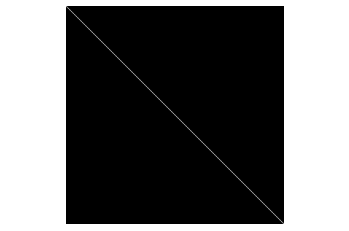

In [16]:
# Let's take the chance to visualise the input-to-output mapping.
plt.imshow(inp2out_map, cmap='gray'); plt.axis('equal'); _ = plt.axis('off')
# black = zero; white = one. We find strictly 1 one on each row, zero everywhere else.

## 2.2 by pandas

In [17]:
tic = time.time()
out = pd.get_dummies(train['cat10'])
tictoc = time.time() - tic
summary.loc['pd.get_dummies'] = redressOutput(out) + (tictoc, )

onehot_encoders = ['sklearn.preprocessing._encoders.OneHotEncoder',
                   'category_encoders.one_hot.OneHotEncoder',
                   'pd.get_dummies']
summary.loc[onehot_encoders, columns_show ]

,nunique,unique,shape,tictoc
encoder,,,,
sklearn.preprocessing._encoders.OneHotEncoder,2,"[0.0, 1.0]","(299, 299)",1.543521
category_encoders.one_hot.OneHotEncoder,2,"[0, 1]","(299, 299)",4.226416
pd.get_dummies,2,"[0, 1]","(299, 299)",0.051011


## 2.3 by keras
But with numeric input only. ```cat10``` is string, not numeric. We would need to first convert from string to numeric.

In [18]:
try:
    utils.to_categorical(train['cat10'])
except Exception as complaint:
    print(complaint)
    print('See, told ya it was going to break.')

invalid literal for int() with base 10: 'LO'
See, told ya it was going to break.


In [19]:
tic = time.time()
borrow = preprocessing.LabelEncoder().fit_transform(train['cat10'])
out = utils.to_categorical(borrow)
tictoc = time.time() - tic
summary.loc['utils.to_categorical'] = redressOutput(out) + (tictoc, )

onehot_encoders = ['sklearn.preprocessing._encoders.OneHotEncoder',
                   'category_encoders.one_hot.OneHotEncoder',
                   'pd.get_dummies',
                   'utils.to_categorical']
summary.loc[onehot_encoders, columns_show ]
# We have at our disposal 4 one-hot encoders by different libraries.

,nunique,unique,shape,tictoc
encoder,,,,
sklearn.preprocessing._encoders.OneHotEncoder,2,"[0.0, 1.0]","(299, 299)",1.543521
category_encoders.one_hot.OneHotEncoder,2,"[0, 1]","(299, 299)",4.226416
pd.get_dummies,2,"[0, 1]","(299, 299)",0.051011
utils.to_categorical,2,"[0.0, 1.0]","(299, 299)",0.303275


### Warning
```keras.utils.to_categorical``` doesn't work with negative input.

In [20]:
def redressOutput(out):
    inp2out_map = pd.concat([pd.DataFrame({'inp': train['cat10']}, columns=['inp']),
                             pd.DataFrame(out, index=train.index)], axis=1).drop_duplicates()
    inp2out_map.set_index('inp', inplace=True, drop=True)
    unik = np.unique(inp2out_map.values)
    return inp2out_map, len(unik), unik, inp2out_map.shape

In [21]:
inp = [0, 1, 2, 3, 4]
out = utils.to_categorical(inp)
len(pd.DataFrame(out).drop_duplicates())
# All good: 5 unique values in, 5 unique values out.

5

In [22]:
inp = [-1, 0, 1, 2, 3]
out = utils.to_categorical(inp)
len(pd.DataFrame(out).drop_duplicates())
# 5 unique values in but just 4 out. What's happening here?

4

In [23]:
inp = [-2, -1, 0, 1, 2]
out = utils.to_categorical(inp)
len(pd.DataFrame(out).drop_duplicates())
# Now it's even worse: 5 unique values in, just 3 unique values out.

3

In [24]:
for before, after in zip (inp, out):
    print(before, after)
# This explains why. Negative values weren't mapped the way we thought. 
# -2 was mapped to the same outcome as 1. 
# -1 got mapped to the same outcome as 2.

-2 [0. 1. 0.]
-1 [0. 0. 1.]
0 [1. 0. 0.]
1 [0. 1. 0.]
2 [0. 0. 1.]


# 3. Binary & Base-N Encoders
Base-N encoding is the superset of 
* binary encoding (N=2);
* one-hot encoding (N=1).
By default ```category_encoders.BaseNEncoder``` takes N=2; the output is there for identical to ```category_encoders.BinaryEncoder```:

In [25]:
summary.loc[ ['category_encoders.binary.BinaryEncoder', 'category_encoders.basen.BaseNEncoder'] ][ columns_show ]

,nunique,unique,shape,tictoc
encoder,,,,
category_encoders.binary.BinaryEncoder,2,"[0, 1]","(299, 10)",0.252719
category_encoders.basen.BaseNEncoder,2,"[0, 1]","(299, 10)",0.220429


In [26]:
tis = summary.loc['category_encoders.binary.BinaryEncoder', 'inp2out_map']
tat = summary.loc['category_encoders.basen.BaseNEncoder', 'inp2out_map']
(tis==tat).all().all()

True

#### But do we really need 10 columns?
2^8, 2^9 = 256, 512 so we should only need 9 columns to binary-encode 299 categories.

In [27]:
tis.apply(lambda x: np.unique(x))
# Column cat10_0 is all zeros and is therefore redundant.

cat10_0       [0]
cat10_1    [0, 1]
cat10_2    [0, 1]
cat10_3    [0, 1]
cat10_4    [0, 1]
cat10_5    [0, 1]
cat10_6    [0, 1]
cat10_7    [0, 1]
cat10_8    [0, 1]
cat10_9    [0, 1]
dtype: object

In [28]:
# We can pass the option drop_invariant=True to avoid that redundancy.
BaseNEncoder(drop_invariant=True).fit_transform(train['cat10'])
# Now the redundant column disappears; we get 9 columns instead of 10.

,cat10_1,cat10_2,cat10_3,cat10_4,cat10_5,cat10_6,cat10_7,cat10_8,cat10_9
id,,,,,,,,,
0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,1,1
3,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
499993,0,0,0,0,0,1,0,1,1
499995,0,0,0,0,1,0,0,0,1
499996,0,0,0,0,0,1,0,0,0


# 4. Count Encoder

In [29]:
summary.loc['category_encoders.count.CountEncoder', 'inp2out_map']
# The count encoder seems to output all sorts of integers.

,cat10
inp,
LO,3154
HJ,2834
DJ,31584
KV,573
DP,23679
...,...
JF,2
BA,1
LK,1


In [30]:
# Let's take a look where those values come from. For sampling sake we take the last 3 values and try to derive them.
out = CountEncoder().fit_transform(train['cat10'], train['target'])
inp, out.tail(3)

([-2, -1, 0, 1, 2],
         cat10
 id           
 499996   3011
 499997    565
 499999   5917)

In [31]:
# Where did 3011 come from?
(train['cat10']=='HC').sum()

3011

In [32]:
# Where did 565 come from?
(train['cat10']=='BF').sum()

565

In [33]:
# Where did 5917 come from?
(train['cat10']=='LM').sum()

5917

# 5. Contrast Encoders
These are [contrast encoders](https://stats.idre.ucla.edu/r/library/r-library-contrast-coding-systems-for-categorical-variables) characterised by the presence of an ```intercept``` in the output.

## 5.1 Helmert Encoder

In [34]:
summary.loc[ 'category_encoders.helmert.HelmertEncoder', 'inp2out_map' ]

,intercept,cat10_0,cat10_1,cat10_2,cat10_3,cat10_4,cat10_5,cat10_6,cat10_7,cat10_8,...,cat10_288,cat10_289,cat10_290,cat10_291,cat10_292,cat10_293,cat10_294,cat10_295,cat10_296,cat10_297
inp,,,,,,,,,,,,,,,,,,,,,
LO,1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
HJ,1,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
DJ,1,0.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
KV,1,0.0,0.0,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
DP,1,0.0,0.0,0.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
JF,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,294.0,-1.0,-1.0,-1.0,-1.0
BA,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,295.0,-1.0,-1.0,-1.0
LK,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,296.0,-1.0,-1.0


## 5.2 Sum Encoder

In [35]:
inp2out_map = summary.loc[ 'category_encoders.sum_coding.SumEncoder', 'inp2out_map' ]
inp2out_map

,intercept,cat10_0,cat10_1,cat10_2,cat10_3,cat10_4,cat10_5,cat10_6,cat10_7,cat10_8,...,cat10_288,cat10_289,cat10_290,cat10_291,cat10_292,cat10_293,cat10_294,cat10_295,cat10_296,cat10_297
inp,,,,,,,,,,,,,,,,,,,,,
LO,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HJ,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DJ,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KV,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DP,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
JF,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
BA,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
LK,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
column_sum = inp2out_map.sum()
column_sum
# This is the signature of sum encoding: except the ```intercept``` column all columns sum to zero.

intercept    299.0
cat10_0        0.0
cat10_1        0.0
cat10_2        0.0
cat10_3        0.0
             ...  
cat10_293      0.0
cat10_294      0.0
cat10_295      0.0
cat10_296      0.0
cat10_297      0.0
Length: 299, dtype: float64

In [37]:
column_sum[ column_sum!= 0 ]

intercept    299.0
dtype: float64

## 5.3 Backward-Difference Encoder

In [38]:
summary.loc[ 'category_encoders.backward_difference.BackwardDifferenceEncoder', 'inp2out_map' ]

,intercept,cat10_0,cat10_1,cat10_2,cat10_3,cat10_4,cat10_5,cat10_6,cat10_7,cat10_8,...,cat10_288,cat10_289,cat10_290,cat10_291,cat10_292,cat10_293,cat10_294,cat10_295,cat10_296,cat10_297
inp,,,,,,,,,,,,,,,,,,,,,
LO,1,-0.996656,-0.993311,-0.989967,-0.986622,-0.983278,-0.979933,-0.976589,-0.973244,-0.9699,...,-0.033445,-0.0301,-0.026756,-0.023411,-0.020067,-0.016722,-0.013378,-0.010033,-0.006689,-0.003344
HJ,1,0.003344,-0.993311,-0.989967,-0.986622,-0.983278,-0.979933,-0.976589,-0.973244,-0.9699,...,-0.033445,-0.0301,-0.026756,-0.023411,-0.020067,-0.016722,-0.013378,-0.010033,-0.006689,-0.003344
DJ,1,0.003344,0.006689,-0.989967,-0.986622,-0.983278,-0.979933,-0.976589,-0.973244,-0.9699,...,-0.033445,-0.0301,-0.026756,-0.023411,-0.020067,-0.016722,-0.013378,-0.010033,-0.006689,-0.003344
KV,1,0.003344,0.006689,0.010033,-0.986622,-0.983278,-0.979933,-0.976589,-0.973244,-0.9699,...,-0.033445,-0.0301,-0.026756,-0.023411,-0.020067,-0.016722,-0.013378,-0.010033,-0.006689,-0.003344
DP,1,0.003344,0.006689,0.010033,0.013378,-0.983278,-0.979933,-0.976589,-0.973244,-0.9699,...,-0.033445,-0.0301,-0.026756,-0.023411,-0.020067,-0.016722,-0.013378,-0.010033,-0.006689,-0.003344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
JF,1,0.003344,0.006689,0.010033,0.013378,0.016722,0.020067,0.023411,0.026756,0.0301,...,0.966555,0.9699,0.973244,0.976589,0.979933,0.983278,-0.013378,-0.010033,-0.006689,-0.003344
BA,1,0.003344,0.006689,0.010033,0.013378,0.016722,0.020067,0.023411,0.026756,0.0301,...,0.966555,0.9699,0.973244,0.976589,0.979933,0.983278,0.986622,-0.010033,-0.006689,-0.003344
LK,1,0.003344,0.006689,0.010033,0.013378,0.016722,0.020067,0.023411,0.026756,0.0301,...,0.966555,0.9699,0.973244,0.976589,0.979933,0.983278,0.986622,0.989967,-0.006689,-0.003344


# Grand summary

In [39]:
summary[columns_show]

,nunique,unique,shape,tictoc
encoder,,,,
sklearn.preprocessing._label.LabelEncoder,299,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(299, 1)",0.109889
sklearn.preprocessing._encoders.OrdinalEncoder,299,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","(299, 1)",0.146098
category_encoders.ordinal.OrdinalEncoder,299,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(299, 1)",0.104805
sklearn.preprocessing._encoders.OneHotEncoder,2,"[0.0, 1.0]","(299, 299)",1.543521
category_encoders.one_hot.OneHotEncoder,2,"[0, 1]","(299, 299)",4.226416
sklearn.preprocessing._label.LabelBinarizer,2,"[0, 1]","(299, 299)",7.235379
category_encoders.binary.BinaryEncoder,2,"[0, 1]","(299, 10)",0.252719
category_encoders.basen.BaseNEncoder,2,"[0, 1]","(299, 10)",0.220429
category_encoders.count.CountEncoder,204,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","(299, 1)",0.177695


This notebook is getting a little long. We've covered simple, one-to-one mapping encoders. Let's do target encoders in another notebook!